<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/Hosts_anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook demonstrates how to detect host-level threats using datasets generated from **Wazuh XDR** and **SIEM logs** collected during an Advanced Persistent Threat (APT) simulation on a cyber-physical system (CPS) testbed.

#**Background**

The dataset used in this notebook was collected during a simulated attack staged over a 5-step kill chain, including PowerShell-based reconnaissance, credential abuse, and lateral movement using native Windows binaries.

The detection approach uses a **binary rule-based feature scoring system**, where selected host-level security events are assigned 1 point if triggered during a specific minute. These features are derived from Wazuh alerts and mapped to MITRE ATT&CK techniques relevant to host compromise, lateral movement using living-off-the-land (LOTL) techniques.

Anomaly scores are then aggregated per minute, and each time window is further enriched with explanations of which security rules or behaviors were triggered. This enables:
- Minute-level anomaly tracking
- Clear rationale for alerts (situation awareness and later LLM support)
- Correlation with anomaly score with OT process and OT network (OPC UA) for fusion-based threat detection.

#Step 1 - Upload dataset (csv file)

In [1]:
# Upload csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded['WazuhEvent_features.csv']))

print("The number of rows and columns in the csv file: ", df.shape)

# preview the first few rows
df.head()

Saving WazuhEvent_features.csv to WazuhEvent_features.csv
The number of rows and columns in the csv file:  (10000, 25)


,Ref,Label,timestamp,agent.id,agent.ip,agent.name,data.win.system.channel,data.win.system.eventID,data.win.system.processID,data.win.eventdata.threat Name,...,data.win.eventdata.user,data.win.eventdata.parentCommandLine,data.win.eventdata.commandLine,data.win.eventdata.payload,rule.level,rule.id,rule.description,rule.mitre.id,rule.mitre.tactic,rule.mitre.technique
0,1,Normal,"May 1, 2025 @ 11:19:38.518",15,10.12.25.3,Windows11,Security,4624.0,852.0,NaN,...,NaN,NaN,NaN,NaN,3,60106,Windows Logon Success,"[""T1078""]","[""Defense Evasion"", Persistence, Privilege Esc...","[""Valid Accounts""]"
1,2,Normal,"May 1, 2025 @ 11:19:38.574",15,10.12.25.3,Windows11,Security,4688.0,4.0,NaN,...,NaN,NaN,C:\\WINDOWS\\system32\\svchost.exe -k wusvcs -p,NaN,3,67027,A process was created.,NaN,NaN,NaN
2,3,Normal,"May 1, 2025 @ 11:19:39.725",15,10.12.25.3,Windows11,Security,4688.0,4.0,NaN,...,NaN,NaN,C:\\Windows\\System32\\Dism\\dismhost.exe {5A2...,NaN,3,67027,A process was created.,NaN,NaN,NaN
3,4,Normal,"May 1, 2025 @ 11:19:39.731",15,10.12.25.3,Windows11,Security,4673.0,4.0,NaN,...,NaN,NaN,NaN,NaN,4,60107,Failed attempt to perform a privileged operation,"[""T1078""]","[""Defense Evasion"", Persistence, Privilege Esc...","[""Valid Accounts""]"
4,5,Normal,"May 1, 2025 @ 11:19:39.731",15,10.12.25.3,Windows11,Security,4688.0,4.0,NaN,...,NaN,NaN,"\""C:\\WINDOWS\\system32\\BackgroundTaskHost.ex...",NaN,3,67027,A process was created.,NaN,NaN,NaN


Expected 10,000 timepoints with 25 columns.

Apart from the 'Ref' and 'Label' columns — which were manually added for indexing and annotating the attack period (Ref #8137 to #9813)—the remaining 23 columns are directly exported from the **Wazuh system’s 'Event' logs under the 'Threat Hunting' module.**

#Step 2 - Dataset preprocessing

In [2]:
import pandas as pd
import numpy as np

# Convert timestamp column to datetime
df['timestamp'] = df['timestamp'].astype(str).str.strip()
df['timestamp'] = pd.to_datetime(df['timestamp'], format="%B %d, %Y @ %H:%M:%S.%f", errors='coerce')

# Convert numeric columns that are mistakenly read as floats with .0
numeric_cols = [
    'data.win.system.eventID',
    'data.win.system.processID',
    'rule.id',
    'rule.level'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Replace NaN with empty strings in string-based feature columns
cols_for_str_rules = [
    'data.win.eventdata.authenticationPackageName',
    'data.win.eventdata.destinationPortName',
    'data.win.eventdata.logonProcessName',
    'data.win.eventdata.parentCommandLine',
    'data.win.eventdata.threat Name'
]
for col in cols_for_str_rules:
    df[col] = df[col].fillna('').astype(str)

In [3]:
# preview the first few rows
df.head(10)

,Ref,Label,timestamp,agent.id,agent.ip,agent.name,data.win.system.channel,data.win.system.eventID,data.win.system.processID,data.win.eventdata.threat Name,...,data.win.eventdata.user,data.win.eventdata.parentCommandLine,data.win.eventdata.commandLine,data.win.eventdata.payload,rule.level,rule.id,rule.description,rule.mitre.id,rule.mitre.tactic,rule.mitre.technique
0,1,Normal,2025-05-01 11:19:38.518,15,10.12.25.3,Windows11,Security,4624,852,,...,NaN,,NaN,NaN,3,60106,Windows Logon Success,"[""T1078""]","[""Defense Evasion"", Persistence, Privilege Esc...","[""Valid Accounts""]"
1,2,Normal,2025-05-01 11:19:38.574,15,10.12.25.3,Windows11,Security,4688,4,,...,NaN,,C:\\WINDOWS\\system32\\svchost.exe -k wusvcs -p,NaN,3,67027,A process was created.,NaN,NaN,NaN
2,3,Normal,2025-05-01 11:19:39.725,15,10.12.25.3,Windows11,Security,4688,4,,...,NaN,,C:\\Windows\\System32\\Dism\\dismhost.exe {5A2...,NaN,3,67027,A process was created.,NaN,NaN,NaN
3,4,Normal,2025-05-01 11:19:39.731,15,10.12.25.3,Windows11,Security,4673,4,,...,NaN,,NaN,NaN,4,60107,Failed attempt to perform a privileged operation,"[""T1078""]","[""Defense Evasion"", Persistence, Privilege Esc...","[""Valid Accounts""]"
4,5,Normal,2025-05-01 11:19:39.731,15,10.12.25.3,Windows11,Security,4688,4,,...,NaN,,"\""C:\\WINDOWS\\system32\\BackgroundTaskHost.ex...",NaN,3,67027,A process was created.,NaN,NaN,NaN
5,6,Normal,2025-05-01 11:19:40.424,16,10.12.25.5,Windows11EWS,Security,4688,4,,...,NaN,,"\""C:\\Program Files\\Common Files\\Siemens\\Au...",NaN,3,67027,A process was created.,NaN,NaN,NaN
6,7,Normal,2025-05-01 11:19:41.064,15,10.12.25.3,Windows11,Security,4688,4,,...,NaN,,C:\\Windows\\System32\\RuntimeBroker.exe -Embe...,NaN,3,67027,A process was created.,NaN,NaN,NaN
7,8,Normal,2025-05-01 11:19:46.947,15,10.12.25.3,Windows11,Security,4688,4,,...,NaN,,taskhostw.exe,NaN,3,67027,A process was created.,NaN,NaN,NaN
8,9,Normal,2025-05-01 11:19:52.631,16,10.12.25.5,Windows11EWS,Security,4688,4,,...,NaN,,"\""C:\\Program Files\\Common Files\\Siemens\\Au...",NaN,3,67027,A process was created.,NaN,NaN,NaN
9,10,Normal,2025-05-01 11:19:52.935,16,10.12.25.5,Windows11EWS,Security,4688,4,,...,NaN,,C:\\WINDOWS\\system32\\DllHost.exe /Processid:...,NaN,3,67027,A process was created.,NaN,NaN,NaN


In [4]:
# Data type
df.dtypes

,0
Ref,int64
Label,object
timestamp,datetime64[ns]
agent.id,int64
agent.ip,object
agent.name,object
data.win.system.channel,object
data.win.system.eventID,int64
data.win.system.processID,int64
data.win.eventdata.threat Name,object


#Step 3 - Anomaly Score Calculation per timepoint

The anomaly features in this notebook were carefully curated through manual analysis of Wazuh event logs to ensure precision and reduce false positives when detecting Living off the Land (LOTL) technqiues.

Each feature corresponds to security-relevant behavior, such as PowerShell script execution, unusual logon activity, or abnormal file transfers.

Only high-confidence indicators were included — for example, rules related to valid account usage were excluded due to their tendency to produce incorrect signals.

The selected features collectively cover key MITRE ATT&CK stages including Initial Access, Execution, Credential Access, and Lateral Movement.

This approach ensures the scoring system remains reliable for real-time and fusion-based threat detection.

Moreover, the rules in Wazuh has enabled us to understand the respective MITRE ATTACK technique ID, which is useful for incident response.

Anomaly features could be easily expanded and adjusted when other threat simulation is conducted in the testbed. This approach provides the flexibility to update the anomaly score criteria.

In [5]:
# Create binary anomaly features
# Assign 1 when the feature detected (1 = anomaly, 0 = not anomaly)
# Expandable list - add more features when needed

# Suspicious connection or logon
df['anomaly_ntlm'] = df['data.win.eventdata.authenticationPackageName'].str.contains('NTLM', case=False, na=False) # NTLM authentication which is subject to NTLM relay attacks.
df['anomaly_epmap'] = df['data.win.eventdata.destinationPortName'].str.contains('epmap', case=False, na=False) # Suspicious "epmap" connection to a remote computer via Remote Procedure Call (RPC).
df['anomaly_logonProcess'] = df['data.win.eventdata.logonProcessName'].str.contains(r'user32|NtLmSsp', case=False, na=False) # Suspicious remote desktop service.
df['anomaly_ruleid_67022'] = df['rule.id'].astype(str) == '67022' # Non network or service local logon.
df['anomaly_ruleid_67024'] = df['rule.id'].astype(str) == '67024' # Service logon event registered from non standard service account.
df['anomaly_ruleid_67028'] = df['rule.id'].astype(str) == '67028' # Special privileges assigned to new logon, related to rule.mitre.id "T1484".
df['anomaly_ruleid_92037'] = df['rule.id'].astype(str) == '92037' # A net.exe connection to a remote resource was started by wsmprovhost.exe, related to rule.mitre.id "T1567".
df['anomaly_ruleid_92105'] = df['rule.id'].astype(str) == '92105' # Possible suspicious access to Windows admin shares, related to rule.mitre.id "T1021.002".
df['anomaly_ruleid_92652'] = df['rule.id'].astype(str) == '92652' # NTLM authentication, possible pass-the-hash attack, related to rule.mitre.id "T1550.002", "T1078.002".
df['anomaly_ruleid_92653'] = df['rule.id'].astype(str) == '92653' # Remote Desktop Connection (RDP), related to rule.mitre.id "T1021.001", "T1078.002".
df['anomaly_ruleid_92657'] = df['rule.id'].astype(str) == '92657' # Successful Remote Logon Detected, NTLM authentication, possible pass-the-hash attack, \
                                                                  # possible RDP connection, related to rule.mitre.id "T1550.002", "T1078.002", "T1021.001".

# Suspicious command line or scripts
df['anomaly_powershell_4104'] = df['data.win.system.eventID'].astype(str).str.contains('4104') # Suspicious PowerShell script.
df['anomaly_cmd_in_parent'] = df['data.win.eventdata.parentCommandLine'].str.contains('cmd.exe', case=False, na=False) # Suspicious use of cmd.exe.
df['anomaly_ruleid_91811'] = df['rule.id'].astype(str) == '91811' # Powershell script executed "Expand-Archive", related to rule.mitre.id "T1105".
df['anomaly_ruleid_91815'] = df['rule.id'].astype(str) == '91815' # Powershell executing process discovery, related to rule.mitre.id "T1057".
df['anomaly_ruleid_91816'] = df['rule.id'].astype(str) == '91816' # Powershell script querying system environment variables, related to rule.mitre.id "T1082".
df['anomaly_ruleid_92021'] = df['rule.id'].astype(str) == '92021' # Powershell was used to delete files or directories, related to rule.mitre.id "T1070.004".
df['anomaly_ruleid_92032'] = df['rule.id'].astype(str) == '92032' # Suspicious Windows cmd shell execution, related to rule.mitre.id "T1087", "T1059.003".
df['anomaly_ruleid_92052'] = df['rule.id'].astype(str) == '92052' # Windows command prompt started by an abnormal process, related to rule.mitre.id "T1059.003".
df['anomaly_ruleid_92068'] = df['rule.id'].astype(str) == '92068' # PSEXEC was used to execute a suspicious command in PowerShell, related to rule.mitre.id "T1569.002".
df['anomaly_ruleid_100206'] = df['rule.id'].astype(str) == '100206' # Invoke Webrequest executed, possible download cradle detected, related to rule.mitre.id "T1059.001".

# Suspicious lateral movement or file transfer
df['anomaly_win_defender'] = df['data.win.eventdata.threat Name'].str.contains('Win32', case=False, na=False) # Threat detection alert from Windows Defender.
df['anomaly_ruleid_62123'] = df['rule.id'].astype(str) == '62123' # Windows Defender: Antimalware platform detected potentially unwanted software.
df['anomaly_ruleid_62124'] = df['rule.id'].astype(str) == '62124' # Windows Defender: Antimalware platform performed an action to protect you from potentially unwanted software
df['anomaly_ruleid_92207'] = df['rule.id'].astype(str) == '92207' # Executable file dropped in Users\Public folder.
df['anomaly_ruleid_92213'] = df['rule.id'].astype(str) == '92213' # Executable file dropped in folder commonly used by malware, related to rule.mitre.id "T1105".
df['anomaly_ruleid_92218'] = df['rule.id'].astype(str) == '92218' # Possible abuse of Windows admin shares by binary dropped in Windows root folder by system process, related to rule.mitre.id "T1570".
df['anomaly_ruleid_92650'] = df['rule.id'].astype(str) == '92650' # New Windows Service Created to start from windows root path. Suspicious event as the binary may have been \
                                                                  # dropped using Windows Admin Shares., related to rule.mitre.id "T1021.002", "T1569.002".

# Other suspicious activities
df['anomaly_medium_or_higher'] = df['rule.level'].apply(lambda x: int(x) >= 7 if str(x).isdigit() else False) # Medum to high severity event defined by Wazuh, where rule.level equals 7 or more.
df['anomaly_ruleid_60776'] = df['rule.id'].astype(str) == '60776' # TrustedInstaller was unavailable to handle a critical notification event.
df['anomaly_ruleid_60635'] = df['rule.id'].astype(str) == '60635' # Windows installer reconfigured the product.


In [6]:
# Combine all anomaly columns into a single anomaly score
anomaly_columns = [col for col in df.columns if col.startswith('anomaly_')]
df['anomaly_score'] = df[anomaly_columns].sum(axis=1)

In [7]:
# Score for each timepoint
df[['timestamp', 'anomaly_score']].head(10)

,timestamp,anomaly_score
0,2025-05-01 11:19:38.518,0
1,2025-05-01 11:19:38.574,0
2,2025-05-01 11:19:39.725,0
3,2025-05-01 11:19:39.731,0
4,2025-05-01 11:19:39.731,0
5,2025-05-01 11:19:40.424,0
6,2025-05-01 11:19:41.064,0
7,2025-05-01 11:19:46.947,0
8,2025-05-01 11:19:52.631,0
9,2025-05-01 11:19:52.935,0


In [8]:
# Sorting the individual anomaly_score from high to low
df[['timestamp', 'anomaly_score']].sort_values(by='anomaly_score', ascending=False).head(10)

,timestamp,anomaly_score
8166,2025-05-02 11:49:30.981,3
8164,2025-05-02 11:49:30.900,3
8163,2025-05-02 11:48:37.098,3
8161,2025-05-02 11:48:36.878,3
8160,2025-05-02 11:47:23.346,3
8157,2025-05-02 11:47:20.685,3
8156,2025-05-02 11:47:18.817,3
8155,2025-05-02 11:46:07.846,3
8153,2025-05-02 11:46:04.168,3
8146,2025-05-02 11:43:05.122,3


#Step 4 - Anomaly Score Aggregation and Explanation by Minute

In [9]:
# Define explanations for each anomaly feature
anomaly_descriptions = {
    'anomaly_ntlm': 'NTLM logon (potential relay attack)',
    'anomaly_epmap': 'Suspicious RPC (epmap) connection',
    'anomaly_logonProcess': 'Suspicious logon process (user32 or NtLmSsp)',
    'anomaly_ruleid_67022': 'Non-network/service logon detected',
    'anomaly_ruleid_67024': 'Service logon from non-standard account',
    'anomaly_ruleid_67028': 'Special privileges assigned to logon [T1484]',
    'anomaly_ruleid_92037': 'Remote net.exe run via wsmprovhost [T1567]',
    'anomaly_ruleid_92105': 'Suspicious access to admin shares [T1021.002]',
    'anomaly_ruleid_92652': 'NTLM pass-the-hash login [T1550.002]',
    'anomaly_ruleid_92653': 'RDP connection detected [T1021.001]',
    'anomaly_ruleid_92657': 'NTLM or RDP remote logon [T1550.002 / T1078.002]',
    'anomaly_powershell_4104': 'Suspicious PowerShell script (4104)',
    'anomaly_cmd_in_parent': 'cmd.exe launched by unusual parent process',
    'anomaly_ruleid_91811': 'PowerShell Expand-Archive run [T1105]',
    'anomaly_ruleid_91815': 'PowerShell process discovery [T1057]',
    'anomaly_ruleid_91816': 'PowerShell queries env variables [T1082]',
    'anomaly_ruleid_92021': 'PowerShell deletes files [T1070.004]',
    'anomaly_ruleid_92032': 'Suspicious Windows cmd shell exec [T1087/T1059.003]',
    'anomaly_ruleid_92052': 'cmd prompt started by suspicious process [T1059.003]',
    'anomaly_ruleid_92068': 'PSEXEC PowerShell exec [T1569.002]',
    'anomaly_ruleid_100206': 'Webrequest download cradle [T1059.001]',
    'anomaly_win_defender': 'Windows Defender detected Win32 threat',
    'anomaly_ruleid_62123': 'Defender found potentially unwanted software',
    'anomaly_ruleid_62124': 'Defender blocked unwanted software',
    'anomaly_ruleid_92207': 'Binary dropped in Users\\Public',
    'anomaly_ruleid_92213': 'Binary in malware-prone directory [T1105]',
    'anomaly_ruleid_92218': 'Binary dropped in Windows root [T1570]',
    'anomaly_ruleid_92650': 'New suspicious Windows service [T1021.002]',
    'anomaly_medium_or_higher': 'Wazuh rule level 7 or above (medium/high severity)',
    'anomaly_ruleid_60776': 'TrustedInstaller failure',
    'anomaly_ruleid_60635': 'Windows installer reconfigured product'
}

In [10]:
# Calculate timestamp per minute
df['timestamp_minute'] = df['timestamp'].dt.floor('min')

# Identify anomaly columns
anomaly_columns = [col for col in df.columns if col.startswith('anomaly_')]

# Create per-minute aggregation with anomaly score, triggered features, and rationale
def summarize_minute(group):
    score = group[anomaly_columns].sum().sum()
    triggered_mask = group[anomaly_columns].any()
    triggered = triggered_mask[triggered_mask].index.tolist()

    # Exclude utility features from rationale explanation
    excluded = {'anomaly_score'}  # add more if needed
    filtered = [f for f in triggered if f not in excluded]

    rationale = "; ".join([anomaly_descriptions.get(f, f) for f in filtered])

    return pd.Series({
        'anomaly_score': score,
        'triggered_features': triggered,
        'rationale_text': rationale
    })


# Apply aggregation by minute
minute_scores = df.groupby('timestamp_minute').apply(summarize_minute).reset_index()

<ipython-input-10-8c91dcfa5400>:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  minute_scores = df.groupby('timestamp_minute').apply(summarize_minute).reset_index()


In [11]:
minute_scores

,timestamp_minute,anomaly_score,triggered_features,rationale_text
0,2025-05-01 11:19:00,0,[],
1,2025-05-01 11:20:00,0,[],
2,2025-05-01 11:21:00,0,[],
3,2025-05-01 11:22:00,0,[],
4,2025-05-01 11:23:00,0,[],
...,...,...,...,...
523,2025-05-02 15:51:00,0,[],
524,2025-05-02 15:52:00,0,[],
525,2025-05-02 15:58:00,0,[],
526,2025-05-02 15:59:00,0,[],


In [12]:
# Extract score with value bigger than 1
anomalous_minutes = minute_scores[minute_scores['anomaly_score'] > 1]

In [13]:
# Sorting of the anomalous minute from largest value to lowest value
anomalous_minutes_sorted = anomalous_minutes.sort_values(by='anomaly_score', ascending=False)

In [14]:
# Result of the anomalous minute (sorted)
anomalous_minutes_sorted

,timestamp_minute,anomaly_score,triggered_features,rationale_text
371,2025-05-02 12:25:00,116,"[anomaly_ntlm, anomaly_logonProcess, anomaly_r...",NTLM logon (potential relay attack); Suspiciou...
435,2025-05-02 13:44:00,116,"[anomaly_ntlm, anomaly_logonProcess, anomaly_r...",NTLM logon (potential relay attack); Suspiciou...
454,2025-05-02 14:03:00,114,"[anomaly_ntlm, anomaly_epmap, anomaly_logonPro...",NTLM logon (potential relay attack); Suspiciou...
376,2025-05-02 12:30:00,48,"[anomaly_ntlm, anomaly_logonProcess, anomaly_r...",NTLM logon (potential relay attack); Suspiciou...
413,2025-05-02 13:15:00,46,"[anomaly_ntlm, anomaly_logonProcess, anomaly_r...",NTLM logon (potential relay attack); Suspiciou...
...,...,...,...,...
429,2025-05-02 13:35:00,2,"[anomaly_medium_or_higher, anomaly_score]",Wazuh rule level 7 or above (medium/high sever...
485,2025-05-02 14:41:00,2,"[anomaly_medium_or_higher, anomaly_score]",Wazuh rule level 7 or above (medium/high sever...
481,2025-05-02 14:35:00,2,"[anomaly_medium_or_higher, anomaly_score]",Wazuh rule level 7 or above (medium/high sever...
497,2025-05-02 15:05:00,2,"[anomaly_medium_or_higher, anomaly_score]",Wazuh rule level 7 or above (medium/high sever...


In [15]:
# Sample one row
row = anomalous_minutes_sorted.iloc[0]
row

,371
timestamp_minute,2025-05-02 12:25:00
anomaly_score,116
triggered_features,"[anomaly_ntlm, anomaly_logonProcess, anomaly_r..."
rationale_text,NTLM logon (potential relay attack); Suspiciou...


In [16]:
# Full list of anomaly score per minute
minute_scores.to_csv('host_anomaly_scores_full.csv', index=False)

# Filtered list with meaningful activity (anomaly score > 0)
anomalous_minutes_sorted = minute_scores[minute_scores['anomaly_score'] > 0].sort_values(by='anomaly_score', ascending=False)
anomalous_minutes_sorted.to_csv('host_anomaly_scores_anomalous_only.csv', index=False)

#Step 5 - Visualisation of 1-minute Anomaly Score

Visualise the result of the entire dataset from 2025 May 01.

The timing of attack simulation is 2025-05-02 11:41 to 2025-05-02 14:39:00.


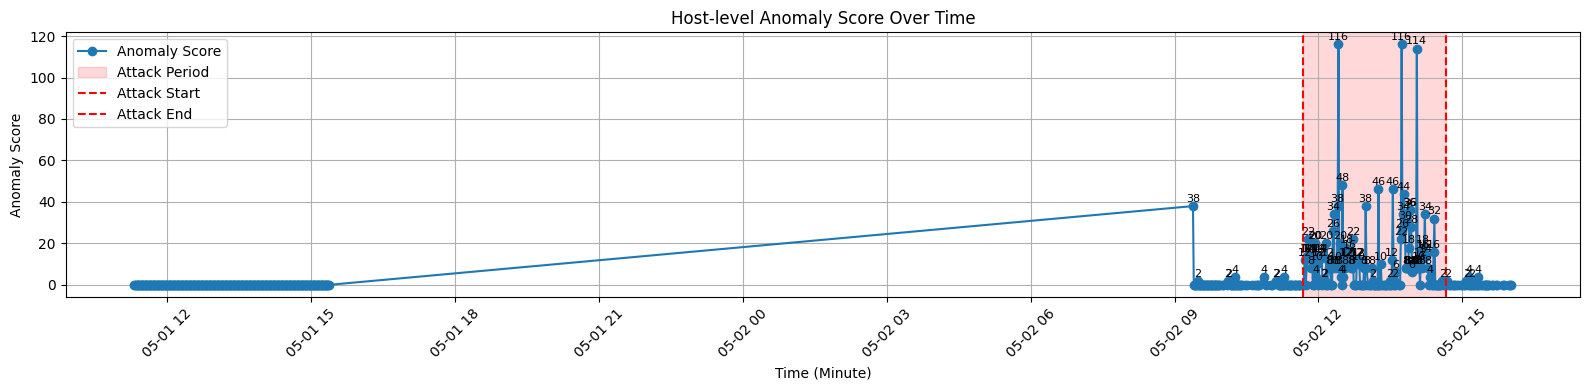

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Define attack period, spanning from approximately 11:41 to 14:39.
attack_start = pd.to_datetime("2025-05-02 11:41:00")
attack_end = pd.to_datetime("2025-05-02 14:39:00")

plt.figure(figsize=(16, 4))

# Plot the anomaly score per minute
plt.plot(minute_scores['timestamp_minute'], minute_scores['anomaly_score'], marker='o', linestyle='-', color='#1f77b4', label='Anomaly Score')

# Annotate each score if non-zero
for x, y in zip(minute_scores['timestamp_minute'], minute_scores['anomaly_score']):
    if y > 0:
        plt.text(x, y + 1, str(int(y)), ha='center', va='bottom', fontsize=8)

# Shade attack zone
plt.axvspan(attack_start, attack_end, color='red', alpha=0.15, label='Attack Period')

# Mark attack period
plt.axvline(x=attack_start, color='red', linestyle='--', label='Attack Start')
plt.axvline(x=attack_end, color='red', linestyle='--', label='Attack End')

# Labels and layout
plt.title('Host-level Anomaly Score Over Time')
plt.xlabel('Time (Minute)')
plt.ylabel('Anomaly Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

There is a visible gap in the time series between May 1st, 15:00 and May 2nd, 09:00 due to the testbed machine being powered off overnight.

In [27]:
# Convert to datetime if not already
minute_scores['timestamp_minute'] = pd.to_datetime(minute_scores['timestamp_minute'])

# Define time range
start_time = pd.to_datetime("2025-05-02 11:43:00")
end_time = pd.to_datetime("2025-05-02 14:25:00")

# Filter for that range and score > 0
narrative_window = minute_scores[
    (minute_scores['timestamp_minute'] >= start_time) &
    (minute_scores['timestamp_minute'] <= end_time) &
    (minute_scores['anomaly_score'] > 0)
].sort_values(by='timestamp_minute')

Replotting the graph to contains only data on May 2 2025.

In [28]:
# Filter to only include May 2, 2025
minute_scores['timestamp_minute'] = pd.to_datetime(minute_scores['timestamp_minute'])

may2_scores = minute_scores[
    (minute_scores['timestamp_minute'] >= '2025-05-02 00:00:00') &
    (minute_scores['timestamp_minute'] <= '2025-05-02 23:59:59')
]


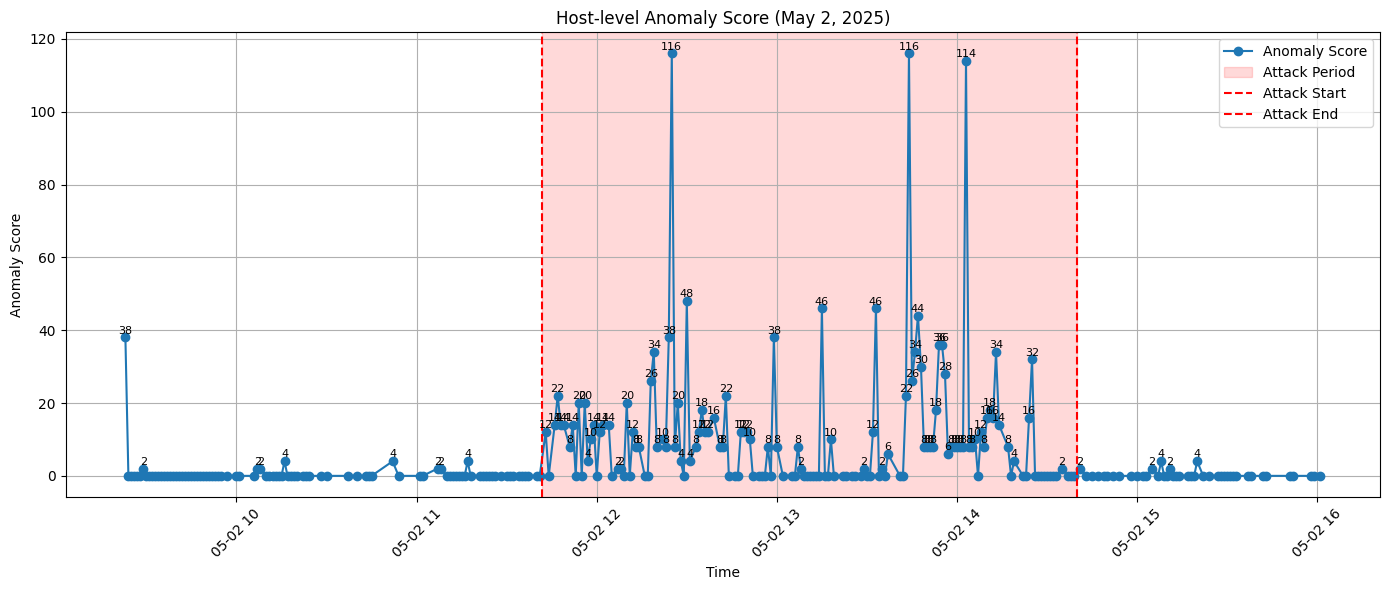

In [29]:
import matplotlib.pyplot as plt

# Define attack period, spanning from approximately 11:41 to 14:39.
attack_start = pd.to_datetime('2025-05-02 11:41:44.204')
attack_end = pd.to_datetime('2025-05-02 14:39:50.162')

plt.figure(figsize=(14, 6))

# Plot the anomaly score per minute
plt.plot(may2_scores['timestamp_minute'], may2_scores['anomaly_score'], marker='o', linestyle='-', color='#1f77b4', label='Anomaly Score')

# Annotate data points
for x, y in zip(may2_scores['timestamp_minute'], may2_scores['anomaly_score']):
    if y > 0:
        plt.text(x, y + 0.5, str(int(y)), ha='center', va='bottom', fontsize=8)

# Shade attack zone
plt.axvspan(attack_start, attack_end, color='red', alpha=0.15, label='Attack Period')

# Mark attack period
plt.axvline(x=attack_start, color='red', linestyle='--', label='Attack Start')
plt.axvline(x=attack_end, color='red', linestyle='--', label='Attack End')

# Add labels and legend
plt.title('Host-level Anomaly Score (May 2, 2025)')
plt.xlabel('Time')
plt.ylabel('Anomaly Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Key observations:

* Significant anomaly scores are concentrated almost entirely within the defined attack window.

* The scoring system effectively correlates with known malicious activities such as NTLM-based relay attempts, suspicious command-line usage, and lateral movement.

* A single early spike at 09:23 (Score: 38) is attributed to legitimate machine startup events and is excluded from the narrative analysis.

Overall, this indicates that the scoring mechanism is effective for distinguishing real threats from benign background noise, supporting its use in real-time fusion-based detection systems.

# Step 6 - List of Anomalies for investigation

In [22]:
def explain_anomalies(df):
    for _, row in df.iterrows():
        print(f"Time {row['timestamp_minute'].strftime('%Y-%m-%d %H:%M')}")
        print(f"Anomaly Score: {row['anomaly_score']}")
        print(f"Explanation: {row['rationale_text']}")
        print('-' * 60)

# Show the explanations
explain_anomalies(narrative_window)

Time 2025-05-02 11:43
Anomaly Score: 12
Explanation: NTLM logon (potential relay attack); Suspicious logon process (user32 or NtLmSsp); NTLM pass-the-hash login [T1550.002]
------------------------------------------------------------
Time 2025-05-02 11:46
Anomaly Score: 14
Explanation: NTLM logon (potential relay attack); Suspicious logon process (user32 or NtLmSsp); Special privileges assigned to logon [T1484]; NTLM pass-the-hash login [T1550.002]
------------------------------------------------------------
Time 2025-05-02 11:47
Anomaly Score: 22
Explanation: NTLM logon (potential relay attack); Suspicious logon process (user32 or NtLmSsp); Special privileges assigned to logon [T1484]; NTLM pass-the-hash login [T1550.002]
------------------------------------------------------------
Time 2025-05-02 11:48
Anomaly Score: 14
Explanation: NTLM logon (potential relay attack); Suspicious logon process (user32 or NtLmSsp); Special privileges assigned to logon [T1484]; NTLM pass-the-hash login

In [24]:
# Sample one row
may2_scores.head(5)

,timestamp_minute,anomaly_score,triggered_features,rationale_text
244,2025-05-02 09:23:00,38,"[anomaly_logonProcess, anomaly_ruleid_67028, a...",Suspicious logon process (user32 or NtLmSsp); ...
245,2025-05-02 09:24:00,0,[],
246,2025-05-02 09:25:00,0,[],
247,2025-05-02 09:26:00,0,[],
248,2025-05-02 09:27:00,0,[],


In [25]:
# Filter for the specific timestamp
investigate_specific_row = may2_scores[may2_scores['timestamp_minute'] == pd.to_datetime('2025-05-02 09:23:00')]

# Use the explanation function
explain_anomalies(investigate_specific_row)

Time 2025-05-02 09:23
Anomaly Score: 38
Explanation: Suspicious logon process (user32 or NtLmSsp); Special privileges assigned to logon [T1484]; cmd prompt started by suspicious process [T1059.003]; Wazuh rule level 7 or above (medium/high severity)
------------------------------------------------------------


The high anomaly score observed at 2025-05-02 09:23 (Score: 38) is not part of the simulated attack sequence. This spike is likely due to legitimate system activity associated with machine startup, such as elevated privileges being assigned, user session initialization, and execution of trusted system processes like PowerShell or command prompt. These actions triggered several rules associated with credential abuse or execution tactics but do not reflect malicious behavior in this context.

To avoid misinterpretation, this timestamp is treated as a false positive due to benign but noisy startup activity and excluded from the attack narrative.

In [21]:
may2_scores.to_csv('host_anomaly_score_may2.csv', index=False)

In [23]:
narrative_window.to_csv("host_anomaly_scores_may2_1143_to_1425.csv", index=False)

The End